# 🧠 Taller ANN Multiclass — Clasificación de Credit Score

## Objetivo
Clasificar clientes en **3 categorías de riesgo crediticio** usando una Red Neuronal Artificial:

| Clase | Etiqueta | Descripción |
|-------|----------|-------------|
| `0`   | **Poor**     | Mal historial crediticio |
| `1`   | **Standard** | Crédito promedio |
| `2`   | **Good**     | Excelente crédito |

## Pipeline
1. 📂 Carga y exploración de datos  
2. 🔧 Preprocesamiento (limpieza, encoding, normalización)  
3. 📉 Reducción de dimensionalidad con **PCA**  
4. 🧠 Construcción y entrenamiento de la **ANN Multiclass**  
5. 📊 Evaluación y visualización de resultados  

**Dataset:** 12,500 clientes × 26 columnas


## ⚡ 0. Configuración de Google Colab

Al parecer tenia un problema con Cuda y decidi hacerlo con google colab por facilidad y rapidez




In [33]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs detectadas: {gpus}")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ Entrenando en GPU de Colab")
else:
    print("⚠️ No se detecta GPU")


TensorFlow: 2.19.0
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Entrenando en GPU de Colab


##  1. Importación de Librerías

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print("✅ Librerías importadas")
print(f"   TensorFlow: {tf.__version__}")
print(f"   Pandas:     {pd.__version__}")


✅ Librerías importadas
   TensorFlow: 2.19.0
   Pandas:     2.2.2


##  2. Carga de Datos

In [35]:
df = pd.read_excel("https://github.com/adiacla/bigdata/raw/master/riesgo.xlsx")
print(f"📐 Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head(5)

📐 Shape: 12,500 filas × 26 columnas


,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,17.375,913-74-1218,Lawyer,30625.94,2706.161667,6.0,5.0,27,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,CUS_0x1009,Arunah,25.750,063-67-6938,Mechanic,52312.68,4250.390000,6.0,5.0,17,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,CUS_0x100b,Shirboni,18.500,238-62-0395,Media_Manager,113781.39,9549.782500,1.0,4.0,1,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,CUS_0x1011,Schneyerh,43.875,793-05-8223,Doctor,58918.47,5208.872500,3.0,3.0,17,...,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,CUS_0x1013,Cameront,43.750,930-49-9615,Mechanic,98620.98,7962.415000,3.0,3.0,6,...,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


## Se utiliza un lector de excel para que sea mas facil usar los datos del excel sin tener que cargarlos directamente


In [57]:
df = pd.read_excel("https://github.com/adiacla/bigdata/raw/master/riesgo.xlsx")

print(f"📐 Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head(5)

📐 Shape: 12,500 filas × 26 columnas


,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,17.375,913-74-1218,Lawyer,30625.94,2706.161667,6.0,5.0,27,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,CUS_0x1009,Arunah,25.750,063-67-6938,Mechanic,52312.68,4250.390000,6.0,5.0,17,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,CUS_0x100b,Shirboni,18.500,238-62-0395,Media_Manager,113781.39,9549.782500,1.0,4.0,1,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,CUS_0x1011,Schneyerh,43.875,793-05-8223,Doctor,58918.47,5208.872500,3.0,3.0,17,...,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,CUS_0x1013,Cameront,43.750,930-49-9615,Mechanic,98620.98,7962.415000,3.0,3.0,6,...,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


## Se revisa nulos o unicos para un preprocesamiento solido

In [58]:
# Resumen de tipos y nulos
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
print(info_df.to_string())


                             Tipo  Nulos  % Nulos  Únicos
Customer_ID                object      0     0.00   12500
Name                       object      0     0.00   10139
Age                       float64      0     0.00     659
SSN                        object      0     0.00   12494
Occupation                 object      0     0.00      15
Annual_Income             float64      0     0.00   12488
Monthly_Inhand_Salary     float64      0     0.00   12491
Num_Bank_Accounts         float64      0     0.00     107
Num_Credit_Card           float64      0     0.00     103
Interest_Rate               int64      0     0.00      34
Num_of_Loan                 int64      0     0.00      10
Type_of_Loan               object   1426    11.41    6260
Delay_from_due_date       float64      0     0.00     518
Num_of_Delayed_Payment    float64      0     0.00     546
Changed_Credit_Limit      float64      0     0.00    5836
Num_Credit_Inquiries      float64      0     0.00     275
Credit_Mix    

##  3. Análisis Exploratorio (EDA)

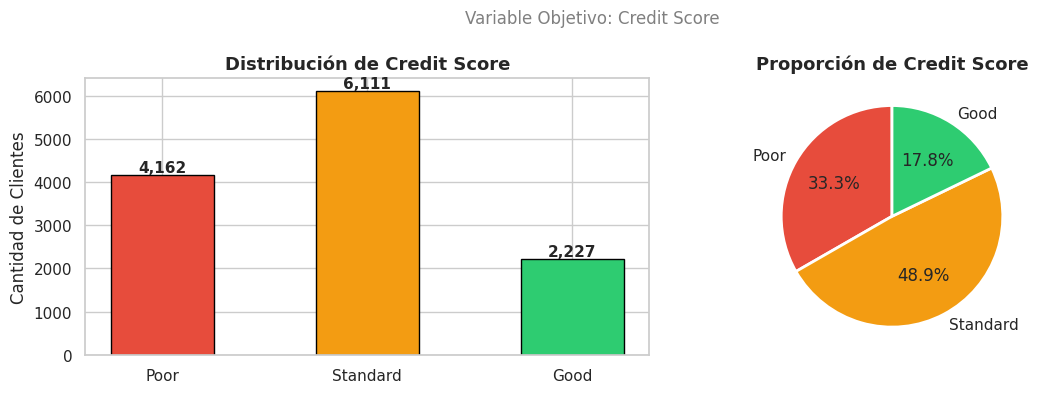

Credit_Score
0    4162
1    6111
2    2227


In [38]:
# Distribución de la variable objetivo
colores = ['#e74c3c', '#f39c12', '#2ecc71']
etiquetas = {0: 'Poor', 1: 'Standard', 2: 'Good'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Credit_Score'].value_counts().sort_index()
bars = axes[0].bar([etiquetas[i] for i in counts.index], counts.values,
                   color=colores, edgecolor='black', width=0.5)
axes[0].set_title('Distribución de Credit Score', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de Clientes')
for bar in bars:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=11)

axes[1].pie(counts.values, labels=[etiquetas[i] for i in counts.index],
            colors=colores, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Credit Score', fontsize=13, fontweight='bold')

plt.suptitle('Variable Objetivo: Credit Score', fontsize=12, color='gray')
plt.tight_layout()
plt.savefig('01_target_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
print(counts.to_string())


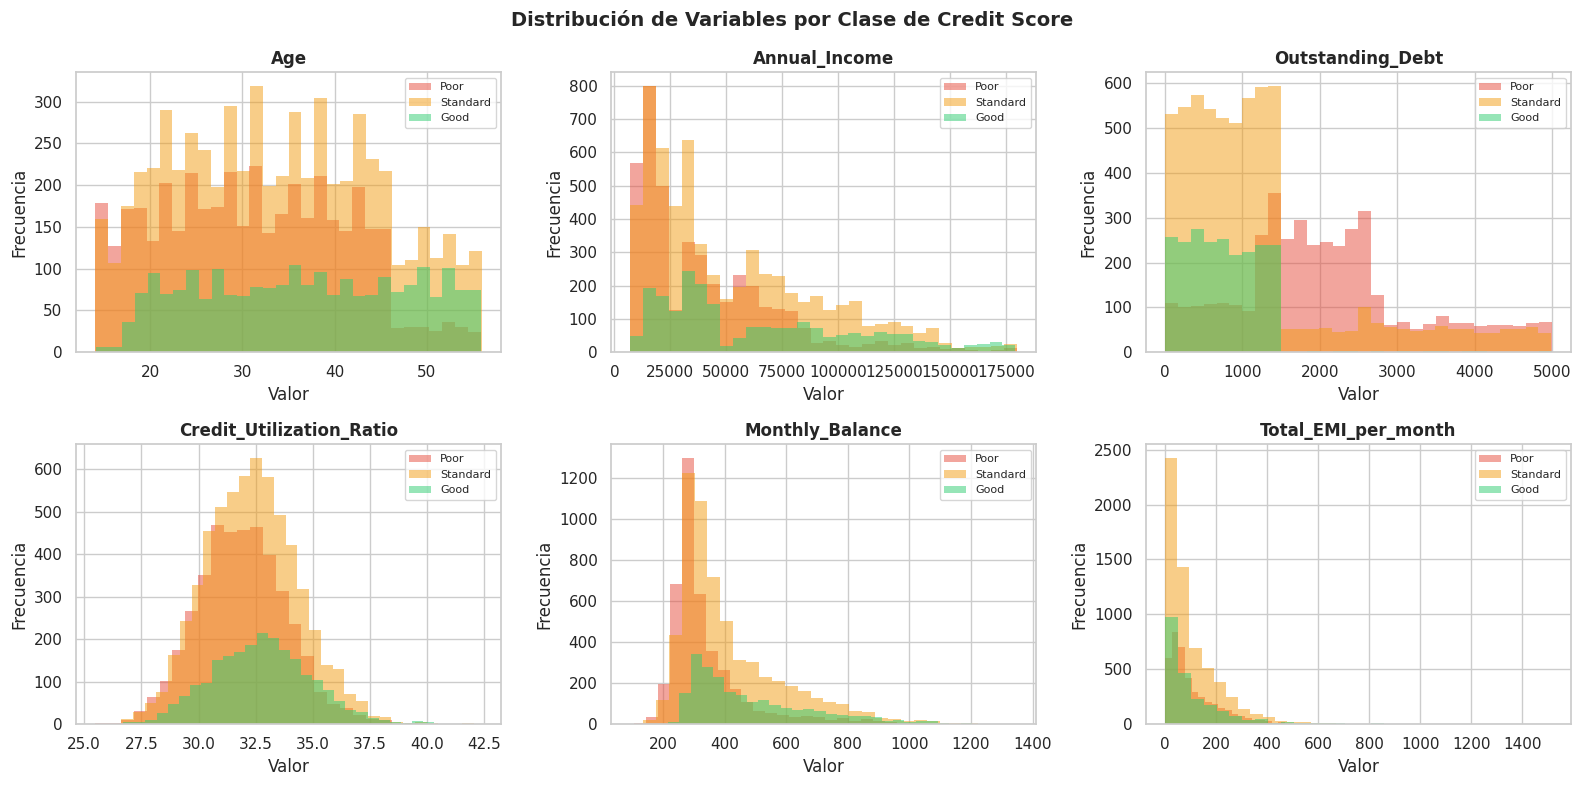

In [39]:
# Distribución de variables numéricas clave por clase
num_features = ['Age', 'Annual_Income', 'Outstanding_Debt',
                'Credit_Utilization_Ratio', 'Monthly_Balance', 'Total_EMI_per_month']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for cls, color, label in zip([0,1,2], colores, ['Poor','Standard','Good']):
        data = df[df['Credit_Score'] == cls][col].dropna()
        axes[i].hist(data, bins=30, alpha=0.5, color=color, label=label, edgecolor='none')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de Variables por Clase de Credit Score',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_dist_variables.png', dpi=150, bbox_inches='tight')
plt.show()


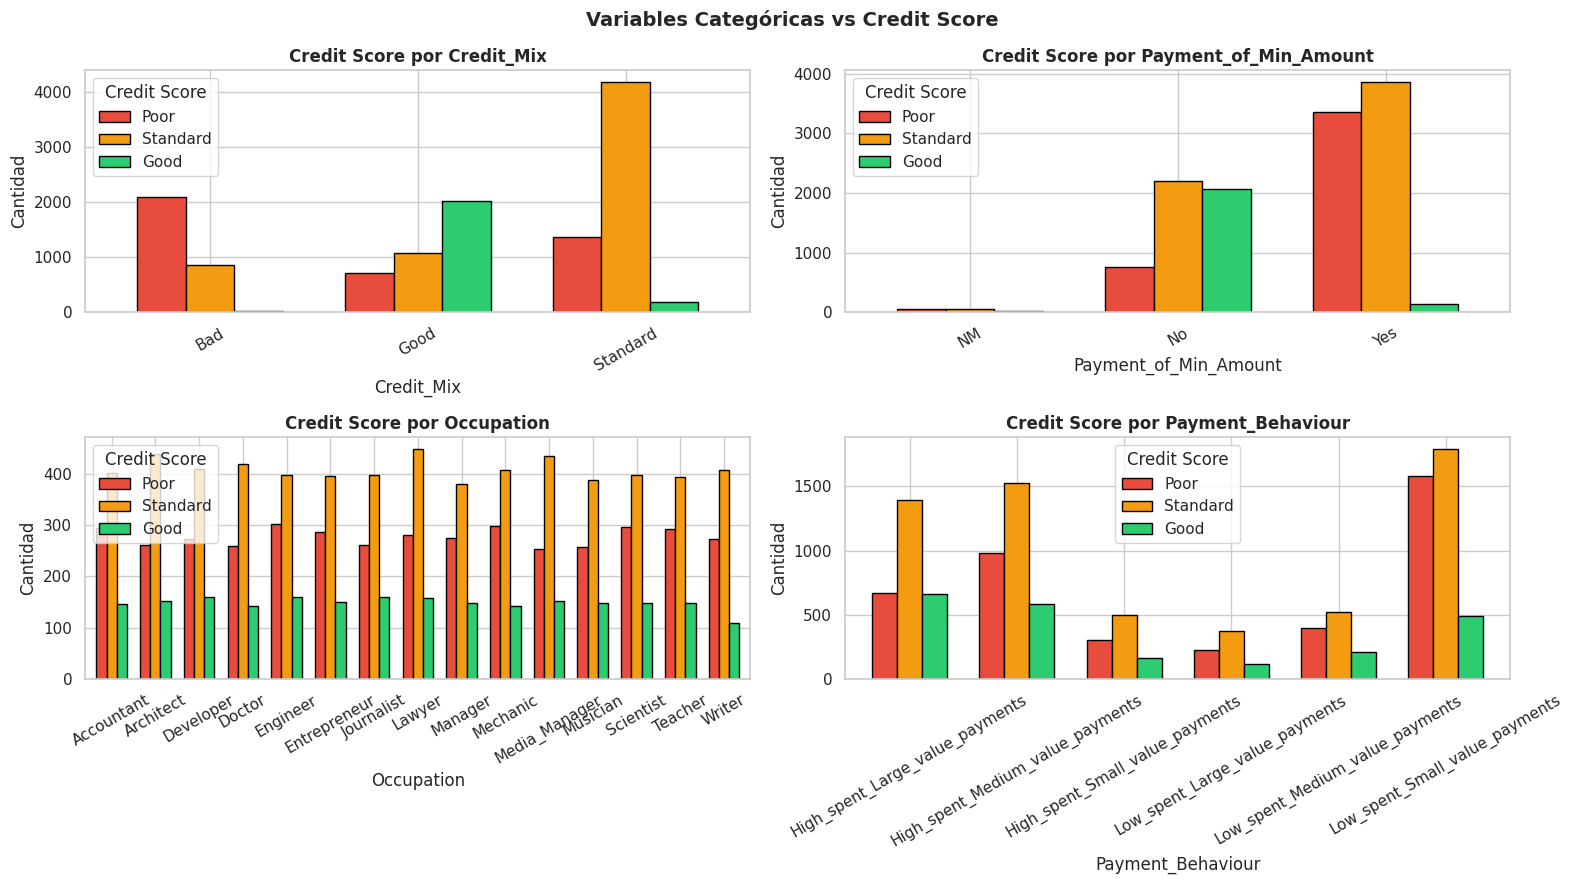

In [40]:
# Variables categóricas
cat_feats = ['Credit_Mix', 'Payment_of_Min_Amount', 'Occupation', 'Payment_Behaviour']

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_feats):
    tabla = df.groupby([col, 'Credit_Score']).size().unstack(fill_value=0)
    tabla.plot(kind='bar', ax=axes[i], color=colores[:tabla.shape[1]],
               edgecolor='black', width=0.7)
    axes[i].set_title(f'Credit Score por {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Poor','Standard','Good'], title='Credit Score')

plt.suptitle('Variables Categóricas vs Credit Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()


##  4. Preprocesamiento de Datos
Se busca elimiar los labels como Costumer_Id y etc, por que no cumplen con una utilidad suficiente para el entrenamineto y se procede a normalizar con StandarScaler
| Paso | Acción |
|------|--------|
| 1 | Eliminar `Customer_ID`, `Name`, `SSN`, `Type_of_Loan` |
| 2 | Imputar nulos con moda/mediana |
| 3 | Codificar variables categóricas con `LabelEncoder` |
| 4 | Normalizar con `StandardScaler` |


In [41]:
df_clean = df.copy()

# 4.1 Eliminar columnas irrelevantes
cols_drop = ['Customer_ID', 'Name', 'SSN', 'Type_of_Loan']
df_clean.drop(columns=[c for c in cols_drop if c in df_clean.columns], inplace=True)
print(f"  Eliminadas: {cols_drop}")
print(f"   Shape: {df_clean.shape}")


✂️  Eliminadas: ['Customer_ID', 'Name', 'SSN', 'Type_of_Loan']
   Shape: (12500, 22)


In [42]:
# 4.2 Separar target antes del encoding
y = df_clean['Credit_Score'].values
df_features = df_clean.drop(columns=['Credit_Score']).copy()

print(f"✅ Target separado: {y.shape}")
print(f"   Clases: {np.unique(y)}  (0=Poor, 1=Standard, 2=Good)")


✅ Target separado: (12500,)
   Clases: [0 1 2]  (0=Poor, 1=Standard, 2=Good)


In [43]:
# 4.3 Codificar columnas categóricas con LabelEncoder
cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

le = LabelEncoder()
print("🏷️  Encoding de columnas categóricas:")
for col in cat_cols:
    df_features[col] = df_features[col].astype(str).fillna('Unknown')
    df_features[col] = le.fit_transform(df_features[col])
    print(f"   {col}: {le.classes_.tolist()} → {list(range(len(le.classes_)))}")


🏷️  Encoding de columnas categóricas:
   Occupation: ['Accountant', 'Architect', 'Developer', 'Doctor', 'Engineer', 'Entrepreneur', 'Journalist', 'Lawyer', 'Manager', 'Mechanic', 'Media_Manager', 'Musician', 'Scientist', 'Teacher', 'Writer'] → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
   Credit_Mix: ['Bad', 'Good', 'Standard'] → [0, 1, 2]
   Payment_of_Min_Amount: ['NM', 'No', 'Yes'] → [0, 1, 2]
   Payment_Behaviour: ['High_spent_Large_value_payments', 'High_spent_Medium_value_payments', 'High_spent_Small_value_payments', 'Low_spent_Large_value_payments', 'Low_spent_Medium_value_payments', 'Low_spent_Small_value_payments'] → [0, 1, 2, 3, 4, 5]


In [44]:
# 4.4 Verificar y corregir tipos numéricos
num_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    df_features[col] = pd.to_numeric(df_features[col], errors='coerce')

# Imputar nulos restantes con mediana
nulos = df_features.isnull().sum()
if nulos.any():
    print("⚠️  Imputando nulos con mediana:")
    print(nulos[nulos > 0])
    df_features.fillna(df_features.median(numeric_only=True), inplace=True)
else:
    print("✅ Sin valores nulos")

print(f"\n📐 Features finales: {df_features.shape}")
print(f"   Columnas: {df_features.columns.tolist()}")


✅ Sin valores nulos

📐 Features finales: (12500, 21)
   Columnas: ['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance']


##  5. Normalización con StandardScaler

Transforma cada feature a media=0 y desviación estándar=1:
$$z = \frac{x - \mu}{\sigma}$$

Esto es **esencial** para que la ANN entrene eficientemente.


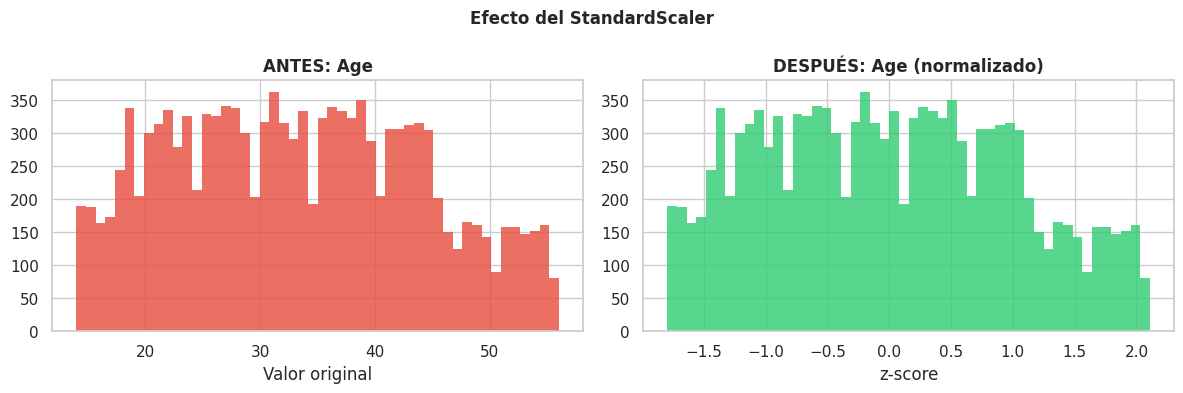

✅ Normalización completada
   Media promedio: 0.000000 (≈ 0)
   Std  promedio:  1.000000  (≈ 1)


In [45]:
X = df_features.values
feature_names = df_features.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificación visual antes/después
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X[:, 0], bins=50, color='#e74c3c', alpha=0.8, edgecolor='none')
axes[0].set_title(f'ANTES: {feature_names[0]}', fontweight='bold')
axes[0].set_xlabel('Valor original')

axes[1].hist(X_scaled[:, 0], bins=50, color='#2ecc71', alpha=0.8, edgecolor='none')
axes[1].set_title(f'DESPUÉS: {feature_names[0]} (normalizado)', fontweight='bold')
axes[1].set_xlabel('z-score')

plt.suptitle('Efecto del StandardScaler', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✅ Normalización completada")
print(f"   Media promedio: {X_scaled.mean():.6f} (≈ 0)")
print(f"   Std  promedio:  {X_scaled.std():.6f}  (≈ 1)")


##  6. Reducción de Dimensionalidad con PCA

**Principal Component Analysis** transforma las features en componentes ortogonales que maximizan la varianza, reduciendo dimensionalidad sin perder información relevante.


📊 Componentes necesarios:
   90% varianza → 12 componentes  (de 21 originales)
   95% varianza → 15 componentes
   99% varianza → 19 componentes


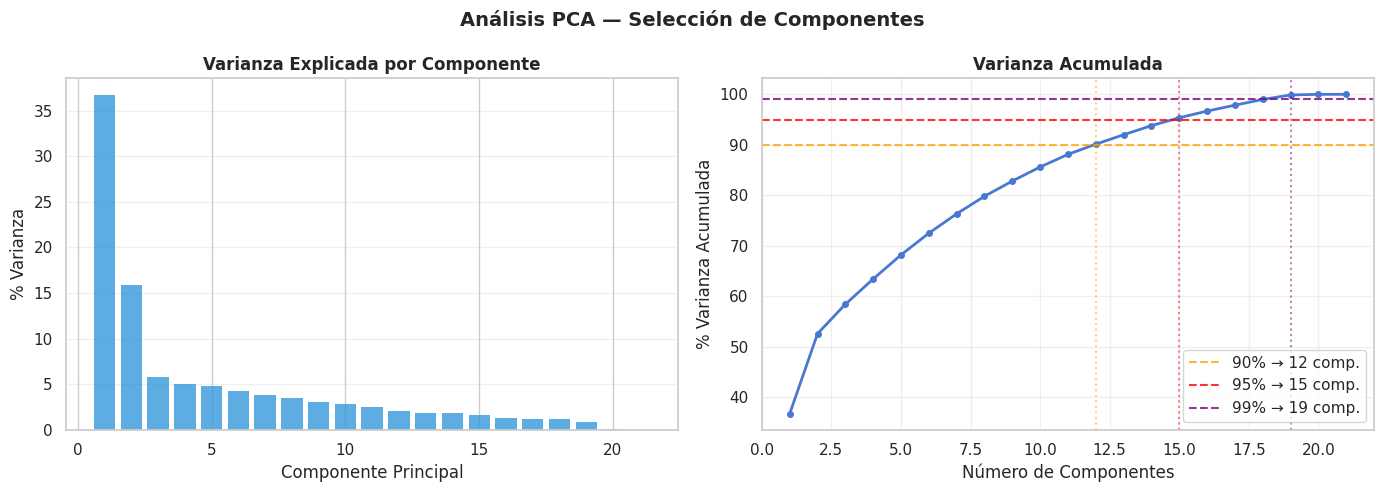

In [46]:
# PCA completo para análisis
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

var_ind = pca_full.explained_variance_ratio_ * 100
var_acum = np.cumsum(var_ind)

n90 = np.argmax(var_acum >= 90) + 1
n95 = np.argmax(var_acum >= 95) + 1
n99 = np.argmax(var_acum >= 99) + 1

print(f" Componentes necesarios:")
print(f"   90% varianza → {n90} componentes  (de {X_scaled.shape[1]} originales)")
print(f"   95% varianza → {n95} componentes")
print(f"   99% varianza → {n99} componentes")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza individual
axes[0].bar(range(1, len(var_ind)+1), var_ind,
            color='#3498db', alpha=0.8, edgecolor='none')
axes[0].set_title('Varianza Explicada por Componente', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('% Varianza')
axes[0].grid(True, alpha=0.3, axis='y')

# Varianza acumulada
axes[1].plot(range(1, len(var_acum)+1), var_acum, 'b-o', markersize=4, linewidth=2)
for n, pct, color in [(n90, 90, 'orange'), (n95, 95, 'red'), (n99, 99, 'purple')]:
    axes[1].axhline(y=pct, color=color, linestyle='--', alpha=0.8,
                    label=f'{pct}% → {n} comp.')
    axes[1].axvline(x=n, color=color, linestyle=':', alpha=0.5)
axes[1].set_title('Varianza Acumulada', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('% Varianza Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis PCA — Selección de Componentes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_pca_analisis.png', dpi=150, bbox_inches='tight')
plt.show()


In [47]:
# Aplicar PCA con 95% de varianza
N_COMPONENTS = n95

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"   PCA aplicado:")
print(f"   Features originales:  {X_scaled.shape[1]}")
print(f"   Componentes PCA:      {N_COMPONENTS}")
print(f"   Varianza conservada:  {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"   Reducción:            {(1 - N_COMPONENTS/X_scaled.shape[1])*100:.1f}% menos dimensiones")


✅ PCA aplicado:
   Features originales:  21
   Componentes PCA:      15
   Varianza conservada:  95.35%
   Reducción:            28.6% menos dimensiones


##  7. División Train / Test (80% / 20%)

In [48]:
# División 70% Train / 10% Val / 20% Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

num_classes = len(np.unique(y))
y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = keras.utils.to_categorical(y_val,   num_classes)
y_test_oh  = keras.utils.to_categorical(y_test,  num_classes)

print(f"✅ División 70% Train / 10% Val / 20% Test")
print(f"   Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"   Val:   {X_val.shape[0]:,} muestras ({X_val.shape[0]/len(y)*100:.0f}%)")
print(f"   Test:  {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(y)*100:.0f}%)")

✅ División 70% Train / 10% Val / 20% Test
   Train: 8,750 muestras (70%)
   Val:   1,250 muestras (10%)
   Test:  2,500 muestras (20%)


##  8. Construcción de la ANN Multiclass

### Arquitectura

```
Input(n_pca)
    ↓
Dense(128, ReLU) → BatchNorm → Dropout(0.3)
    ↓
Dense(64,  ReLU) → BatchNorm → Dropout(0.2)
    ↓
Dense(32,  ReLU) → Dropout(0.2)
    ↓
Dense(3, Softmax)  ← Salida: probabilidad de cada clase
```

- **ReLU**: evita el problema del gradiente desvanecido
- **BatchNormalization**: estabiliza y acelera el entrenamiento
- **Dropout**: regularización contra overfitting
- **Softmax**: convierte activaciones en probabilidades (suma = 1)
- **Categorical Crossentropy**: función de pérdida para multiclase


In [49]:
tf.random.set_seed(42)
np.random.seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],), name='entrada'),

    # Bloque 1
    layers.Dense(128, activation='relu', name='dense_1'),
    layers.BatchNormalization(name='bn_1'),
    layers.Dropout(0.3, name='dropout_1'),

    # Bloque 2
    layers.Dense(64, activation='relu', name='dense_2'),
    layers.BatchNormalization(name='bn_2'),
    layers.Dropout(0.2, name='dropout_2'),

    # Bloque 3
    layers.Dense(32, activation='relu', name='dense_3'),
    layers.Dropout(0.2, name='dropout_3'),

    # Salida multiclase
    layers.Dense(num_classes, activation='softmax', name='salida')
], name='ANN_CreditScore_Multiclass')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "ANN_CreditScore_Multiclass"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,251 (51.76 KB)

 Trainable params: 12,867 (50.26 KB)

 Non-trainable params: 384 (1.50 KB)

##  9. Entrenamiento del Modelo

**Callbacks:**
- `EarlyStopping`: detiene si `val_loss` no mejora en 15 épocas (restaura los mejores pesos)
- `ReduceLROnPlateau`: reduce el learning rate a la mitad si se estanca 7 épocas


In [50]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),   # ← único cambio
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

epocas = len(history.history['loss'])
print(f"\n✅ Entrenamiento finalizado en {epocas} épocas")


Epoch 1/150
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5601 - loss: 1.0187 - val_accuracy: 0.6928 - val_loss: 0.6727 - learning_rate: 0.0010
Epoch 2/150
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6921 - loss: 0.7054 - val_accuracy: 0.7112 - val_loss: 0.6351 - learning_rate: 0.0010
Epoch 3/150
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7088 - loss: 0.6682 - val_accuracy: 0.7232 - val_loss: 0.6273 - learning_rate: 0.0010
Epoch 4/150
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7201 - loss: 0.6532 - val_accuracy: 0.7288 - val_loss: 0.6146 - learning_rate: 0.0010
Epoch 5/150
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7192 - loss: 0.6323 - val_accuracy: 0.7352 - val_loss: 0.6098 - learning_rate: 0.0010
Epoch 6/150
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7331 - loss: 0.6204 - val_accuracy: 0.7480 - val_loss: 0.6038 - learning_rate: 0.0010
Epoch 7/150
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7300 - loss: 0

In [62]:
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)

print(f"Loss:     {test_loss:.4f}")
print(f"Accuracy: {test_acc*100:.2f}%")

Loss:     0.6082
Accuracy: 75.08%


##  10. Curvas de Entrenamiento

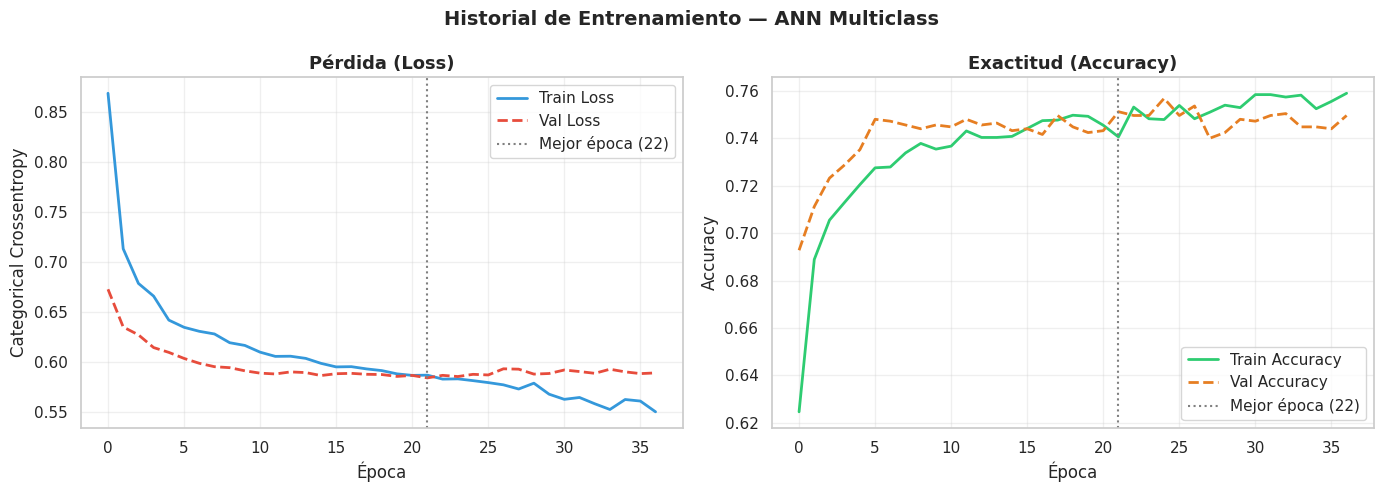

📊 Mejor época: 22
   Val Loss:     0.5843
   Val Accuracy: 75.12%


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_ep = np.argmin(history.history['val_loss'])

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', lw=2, ls='--')
axes[0].axvline(x=best_ep, color='gray', ls=':', label=f'Mejor época ({best_ep+1})')
axes[0].set_title('Pérdida (Loss)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#e67e22', lw=2, ls='--')
axes[1].axvline(x=best_ep, color='gray', ls=':', label=f'Mejor época ({best_ep+1})')
axes[1].set_title('Exactitud (Accuracy)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Historial de Entrenamiento — ANN Multiclass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Mejor época: {best_ep+1}")
print(f"   Val Loss:     {history.history['val_loss'][best_ep]:.4f}")
print(f"   Val Accuracy: {history.history['val_accuracy'][best_ep]*100:.2f}%")


##  11. Evaluación en Conjunto de Test

In [52]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)

print("=" * 55)
print("        RESULTADOS EN CONJUNTO DE TEST")
print("=" * 55)
print(f"  Loss:      {test_loss:.4f}")
print(f"  Accuracy:  {test_acc * 100:.2f}%")
print("=" * 55)


        RESULTADOS EN CONJUNTO DE TEST
  Loss:      0.6082
  Accuracy:  75.08%


In [66]:
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("Guardados correctamente")

Guardados correctamente


In [67]:
from google.colab import files
files.download('modelo_credit_score.keras')
files.download('scaler.pkl')
files.download('pca.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
import os
print(os.getcwd())          # carpeta actual
print(os.listdir('.'))      # archivos en esa carpeta

/content
['.config', '03_categoricas.png', '07_confianza.png', '04_pca_analisis.png', 'modelo_credit_score.h5', '01_target_distribucion.png', 'scaler.pkl', '02_dist_variables.png', '05_training_history.png', '06_confusion_matrix.png', 'label_encoder.pkl', 'modelo_credit_score.keras', 'pca.pkl', 'sample_data']


## Clasificacion de los labels


In [53]:
class_labels = ['Poor (0)', 'Standard (1)', 'Good (2)']
print("\n📋 REPORTE DE CLASIFICACIÓN DETALLADO")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=class_labels))



📋 REPORTE DE CLASIFICACIÓN DETALLADO
------------------------------------------------------------
              precision    recall  f1-score   support

    Poor (0)       0.83      0.68      0.75       833
Standard (1)       0.80      0.76      0.78      1222
    Good (2)       0.57      0.85      0.69       445

    accuracy                           0.75      2500
   macro avg       0.74      0.77      0.74      2500
weighted avg       0.77      0.75      0.75      2500



##  12. Matriz de Confusión

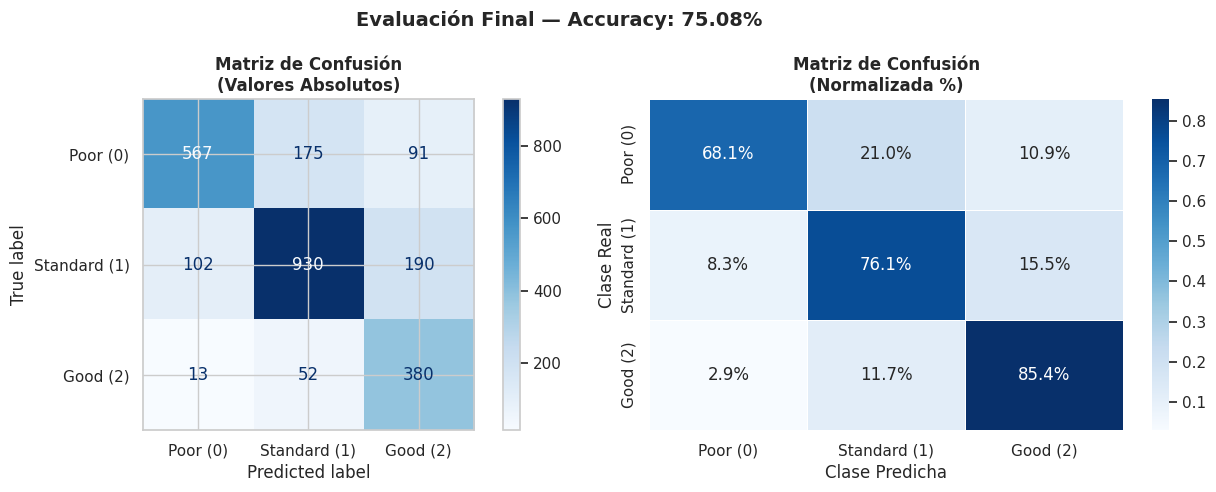


📌 Accuracy por clase:
   Poor (0): 68.1% correctamente clasificados
   Standard (1): 76.1% correctamente clasificados
   Good (2): 85.4% correctamente clasificados


In [54]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valores absolutos
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title('Matriz de Confusión\n(Valores Absolutos)', fontsize=12, fontweight='bold')

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Matriz de Confusión\n(Normalizada %)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Clase Predicha')

plt.suptitle(f'Evaluación Final — Accuracy: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Accuracy por clase:")
for i, label in enumerate(class_labels):
    acc_cls = cm_norm[i, i]
    print(f"   {label}: {acc_cls*100:.1f}% correctamente clasificados")


##  13. Análisis de Confianza del Modelo

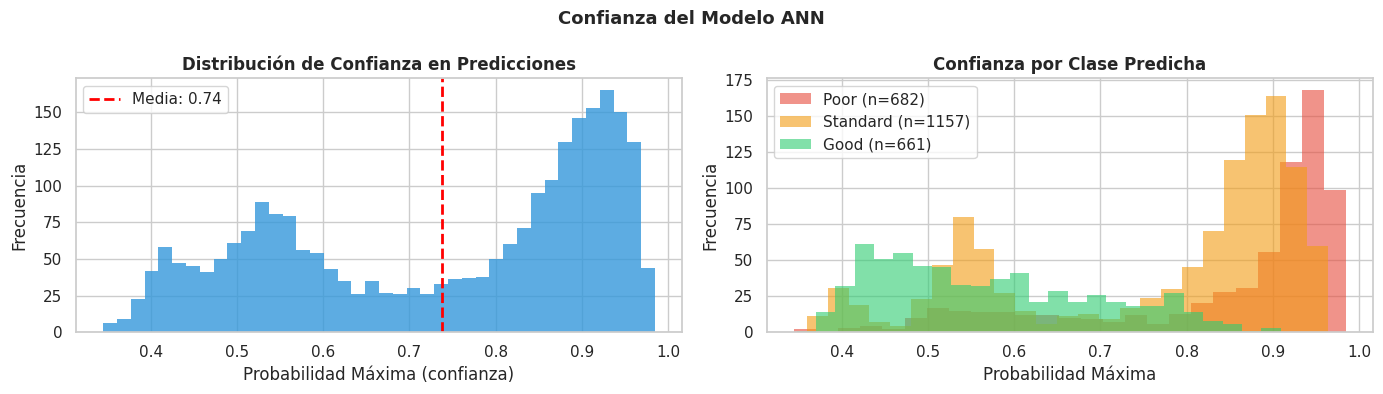


📊 Estadísticas de confianza:
   Media:  73.8%
   Mínimo: 34.5%
   Máximo: 98.5%
   Predicciones con >90% confianza: 688 (27.5%)


In [55]:
max_proba = y_pred_proba.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(max_proba, bins=40, color='#3498db', alpha=0.8, edgecolor='none')
axes[0].axvline(x=max_proba.mean(), color='red', lw=2, ls='--',
                label=f'Media: {max_proba.mean():.2f}')
axes[0].set_title('Distribución de Confianza en Predicciones', fontweight='bold')
axes[0].set_xlabel('Probabilidad Máxima (confianza)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

for cls, color, label in zip([0,1,2], colores, ['Poor','Standard','Good']):
    mask = y_pred == cls
    if mask.any():
        axes[1].hist(max_proba[mask], bins=25, alpha=0.6, color=color,
                     label=f'{label} (n={mask.sum()})', edgecolor='none')
axes[1].set_title('Confianza por Clase Predicha', fontweight='bold')
axes[1].set_xlabel('Probabilidad Máxima')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('Confianza del Modelo ANN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_confianza.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Estadísticas de confianza:")
print(f"   Media:  {max_proba.mean()*100:.1f}%")
print(f"   Mínimo: {max_proba.min()*100:.1f}%")
print(f"   Máximo: {max_proba.max()*100:.1f}%")
print(f"   Predicciones con >90% confianza: {(max_proba>0.9).sum()} ({(max_proba>0.9).mean()*100:.1f}%)")


##  14. Resumen Final del Taller

In [56]:
print("=" * 65)
print("         RESUMEN FINAL — TALLER ANN MULTICLASS")
print("=" * 65)
print()
print("📂 DATASET")
print(f"   Registros:                  12,500 clientes")
print(f"   Features originales:        {X.shape[1]}")
print(f"   Clase 0 (Poor):             {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"   Clase 1 (Standard):         {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")
print(f"   Clase 2 (Good):             {(y==2).sum()} ({(y==2).mean()*100:.1f}%)")
print()
print("🔧 PREPROCESAMIENTO")
print(f"   Eliminadas:                 Customer_ID, Name, SSN, Type_of_Loan")
print(f"   Encoding:                   LabelEncoder (4 columnas)")
print(f"   Normalización:              StandardScaler (z-score)")
print()
print("📉 PCA")
print(f"   Componentes seleccionados:  {N_COMPONENTS} (95% varianza)")
print(f"   Reducción dimensional:      {X.shape[1]} → {N_COMPONENTS}")
print(f"   Varianza conservada:        {pca.explained_variance_ratio_.sum()*100:.2f}%")
print()
print("🧠 ARQUITECTURA ANN")
print(f"   Estructura:                 {X_train.shape[1]} → 128 → 64 → 32 → 3")
print(f"   Activación ocultas:         ReLU + BatchNorm + Dropout")
print(f"   Activación salida:          Softmax (multiclase)")
print(f"   Optimizer:                  Adam (lr=0.001)")
print(f"   Loss:                       Categorical Crossentropy")
print()
print("📊 RESULTADOS")
print(f"   Épocas entrenadas:          {len(history.history['loss'])}")
print(f"   Accuracy en Test:           {test_acc*100:.2f}%")
print(f"   Loss en Test:               {test_loss:.4f}")
print(f"   Confianza promedio:         {max_proba.mean()*100:.1f}%")
print()



         RESUMEN FINAL — TALLER ANN MULTICLASS

📂 DATASET
   Registros:                  12,500 clientes
   Features originales:        21
   Clase 0 (Poor):             4162 (33.3%)
   Clase 1 (Standard):         6111 (48.9%)
   Clase 2 (Good):             2227 (17.8%)

🔧 PREPROCESAMIENTO
   Eliminadas:                 Customer_ID, Name, SSN, Type_of_Loan
   Encoding:                   LabelEncoder (4 columnas)
   Normalización:              StandardScaler (z-score)

📉 PCA
   Componentes seleccionados:  15 (95% varianza)
   Reducción dimensional:      21 → 15
   Varianza conservada:        95.35%

🧠 ARQUITECTURA ANN
   Estructura:                 15 → 128 → 64 → 32 → 3
   Activación ocultas:         ReLU + BatchNorm + Dropout
   Activación salida:          Softmax (multiclase)
   Optimizer:                  Adam (lr=0.001)
   Loss:                       Categorical Crossentropy

📊 RESULTADOS
   Épocas entrenadas:          37
   Accuracy en Test:           75.08%
   Loss en Test:      